<a href="https://colab.research.google.com/github/abhi26shakya/Customer-Churn-Rate-Prediction-Project/blob/main/Customer_Churn_Rate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,75682867,Customer_0,460,Spain,Male,58,5,22843.53,2,0,0,93110.80,1
1,2,66755036,Customer_1,506,Spain,Female,66,3,78706.46,1,1,0,95100.80,1
2,3,66882282,Customer_2,638,Germany,Female,30,8,10763.10,3,1,1,66471.00,0
3,4,31081788,Customer_3,849,Germany,Male,51,5,195240.97,2,0,0,104706.10,1
4,5,23315092,Customer_4,827,Spain,Female,62,3,99556.95,1,1,1,36590.59,0


In [3]:
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [4]:
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [8]:
ann = tf.keras.models.Sequential()

# First hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# Second hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# Output layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [9]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
history = ann.fit(X_train, y_train, batch_size=50, epochs=250, validation_split=0.2)

Epoch 1/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9625 - loss: 0.0833 - val_accuracy: 0.9250 - val_loss: 0.1633
Epoch 2/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9625 - loss: 0.0832 - val_accuracy: 0.9250 - val_loss: 0.1627
Epoch 3/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.0831 - val_accuracy: 0.9187 - val_loss: 0.1632
Epoch 4/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9625 - loss: 0.0825 - val_accuracy: 0.9187 - val_loss: 0.1643
Epoch 5/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.0820 - val_accuracy: 0.9187 - val_loss: 0.1630
Epoch 6/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9625 - loss: 0.0821 - val_accuracy: 0.9250 - val_loss: 0.1618
Epoch 7/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9625 - loss: 0.0820 - val_accuracy: 0.9187 - val_loss: 0.1620
Epoch 8/250
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9625 - loss: 0.0807 - val_accuracy: 0.9250 

In [13]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Confusion Matrix:
 [[110   6]
 [  5  79]]
Accuracy: 0.945


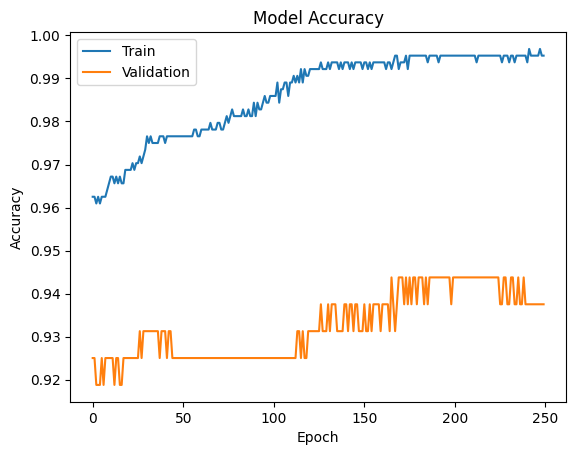

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()